# Разведочный анализ датасета ОФД для NER товаров и брендов

Прежде чем дообучать NER-модель на извлечение товаров и брендов из чековых
позиций, нужно как следует понять данные. Датасет - это размеченная часть
соревнования по структуризации чеков ОФД (Альфа-Банк, Data Fest 2023):
для каждой чековой позиции указаны нормализованный товар (`good`) и
нормализованный бренд (`brand`).

Ключевой вопрос: в каком виде
даны метки? Если товар и бренд присутствуют в исходном тексте позиции как
подстроки, мы можем построить классическую span-разметку (BIO) и обучать
token-classification NER. Если же метки нормализованы (другой регистр,
словоформа, язык), часть из них не находится в тексте дословно, и это
ограничивает применимость span-подхода.

В этом ноутбуке мы выясняем:
- какова структура и объём данных, есть ли пропуски;
- насколько полны метки товара и бренда (много ли пустых брендов);
- какая доля меток реально находится в исходном тексте как
  подстрока, то есть пригодна для span-разметки;
- какие бывают расхождения между меткой и текстом и насколько они системны;
- как устроены тексты позиций: длина, язык, лексика.

## Запуск в Google Colab

Ноутбук я специально подготовила для удобного запуска в Colab без ручных скачиваний.
Код и данные подтягиваются из удалённых источников автоматически.

In [1]:
# Настройка окружения для Colab
import os
import sys
import subprocess
from pathlib import Path
import gdown

IN_COLAB = "google.colab" in sys.modules
# Публичный git-репозиторий с кодом проекта.
REPO_URL = "https://github.com/ScarletFlame611/Receipt-AI.git"
# id файла train_supervised.csv на Google Drive
OFD_GDRIVE_ID = "1VjvhgFEwguDDc_rE2B-q82tfyoxRnTYl"


def _find_project_root():
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / "src").is_dir():
            return cand
    for sub in sorted(p for p in here.iterdir() if p.is_dir()):
        if (sub / "src").is_dir():
            return sub
    return None

if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install",
         "pandas", "numpy", "matplotlib", "seaborn", "transformers", "gdown"],
        check=False,
    )
    if _find_project_root() is None and "USER/" not in REPO_URL:
        subprocess.run(["git", "clone", REPO_URL], check=True)
root = _find_project_root()
if root is None:
    raise RuntimeError(
        "Не найден код проекта"
    )
os.chdir(root)
sys.path.insert(0, str(root))
print("Colab:", IN_COLAB, "| корень проекта:", root)

def ensure_ofd_csv(root):
    dst = Path(root) / "data" / "raw" / "ofd" / "train_supervised.csv"
    if dst.exists():
        return dst
    dst.parent.mkdir(parents=True, exist_ok=True)
    print("OFD CSV не найден локально, качаем с Google Drive")
    gdown.download(id=OFD_GDRIVE_ID, output=str(dst), quiet=False)
    return dst

Colab: True | корень проекта: /content/Receipt-AI


## Загрузка данных

Читаем датасет и смотрим на структуру: размер, колонки, типы, первые строки
и наличие пропусков.

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
fig_dir = root / "notebooks" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{name}.png", bbox_inches="tight")

ofd_path = root / "data" / "raw" / "ofd" / "train_supervised.csv"
ensure_ofd_csv(root)
print("Путь к данным:", ofd_path)
print("Файл существует:", ofd_path.exists())

OFD CSV не найден локально, качаем с Google Drive


Downloading...
From: https://drive.google.com/uc?id=1VjvhgFEwguDDc_rE2B-q82tfyoxRnTYl
To: /content/Receipt-AI/data/raw/ofd/train_supervised.csv
100%|██████████| 2.40M/2.40M [00:00<00:00, 21.0MB/s]

Путь к данным: /content/Receipt-AI/data/raw/ofd/train_supervised.csv
Файл существует: True


In [3]:
df = pd.read_csv(ofd_path)

print("Размер:", df.shape)
print("Колонки:", df.columns.tolist())
print("\nПропуски:\n", df.isna().sum())
print("\nПервые 10 строк:")
print(df.head(10).to_string())

Размер: (25000, 4)
Колонки: ['id', 'name', 'good', 'brand']

Пропуски:
 id          0
name        0
good      819
brand    8505
dtype: int64

Первые 10 строк:
   id                                                            name        good          brand
0   0                         Petmax Бантик леопард с красн розой 2шт      бантик         petmax
1   1                                87191 Бусы для елки шарики_87191        бусы            NaN
2   2                              Футболка Piazza Italia WR011446881    футболка  piazza italia
3   3                  7) YI572-03X-ONE ЗАКОЛКА ДЛЯ ВОЛОС ДЛЯ ДЕВОЧКИ     заколка            NaN
4   4                                               Одежда (вес) 1500      одежда            NaN
5   5                         РУСАЛОЧКА Губка ТРИО трехслой.3 шт ЛЮКС       губка      русалочка
6   6      29-003 ОБОИ/ART/п.п. белые на флизе 1,06*10/островки/9//52        обои            NaN
7   7                                  Квас Очаковский Пряная зим

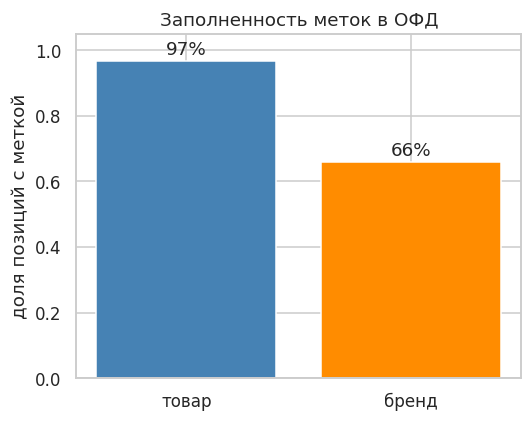

In [4]:
present = [df["good"].notna().mean(), df["brand"].notna().mean()]
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["товар", "бренд"], present, color=["steelblue", "darkorange"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("доля позиций с меткой")
ax.set_title("Заполненность меток в ОФД")
for b, v in zip(bars, present):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.0%}", ha="center")
savefig("ofd_label_completeness")
plt.show()

### Что показала загрузка

Датасет содержит 25 000 размеченных чековых позиций, по четыре колонки:
`id`, `name` (сырой текст позиции), `good` (нормализованный товар),
`brand` (нормализованный бренд).


- Товар почти всегда размечен: пропусков 819 из 25 000, около 3.3%.
  То есть товарная метка есть практически у каждой позиции.
- Бренд отсутствует часто: пропусков 8505 из 25 000, около 34%.
  У трети позиций бренда нет вовсе. Это не ошибка разметки, а природа данных:
  у многих товаров бренда
  действительно нет. Для модели это значит, что отсутствие бренда
  это нормальный ответ полноценный, и метрику по бренду надо считать только там, где он есть,
  а саму модель учить не выдумывать бренд на пустом месте.

Уже по первым строкам заметно главное расхождение, ради которого затевался
анализ: метки нормализованы а не вырезаны из текста. `petmax` в тексте
написан как `Petmax` (отличается регистр), а в строке 8 бренд `cosy` в тексте записан внутри
`COSY` в верхнем регистре. Насколько это мешает span-разметке, измерим
численно в следующем разделе.

## Главный вопрос: находятся ли метки в тексте

Чтобы строить span-разметку (BIO) для token-classification NER, метка товара
и бренда должна присутствовать в исходном тексте позиции как подстрока, иначе
её некуда поставить в последовательности токенов. Метки здесь нормализованы,
поэтому точного совпадения ждать нельзя, но проверим совпадение без учёта
регистра. Доля найденных меток напрямую определяет, какая часть данных пригодна
для span-подхода и сколько мы потеряем, если пойдём по нему.

In [5]:
def is_substr(label, text):
    if pd.isna(label):
        return None
    return str(label).lower().strip() in str(text).lower()

df["good_found"] = [is_substr(g, n) for g, n in zip(df["good"], df["name"])]
df["brand_found"] = [is_substr(b, n) for b, n in zip(df["brand"], df["name"])]

good_rate = df.loc[df["good"].notna(), "good_found"].mean()
brand_rate = df.loc[df["brand"].notna(), "brand_found"].mean()

print(f"good найден как подстрока:  {good_rate:.1%}  (из непустых good)")
print(f"brand найден как подстрока: {brand_rate:.1%}  (из непустых brand)")
print()
print("Непустых good:", df['good'].notna().sum())
print("Непустых brand:", df['brand'].notna().sum())

good найден как подстрока:  93.1%  (из непустых good)
brand найден как подстрока: 85.1%  (из непустых brand)

Непустых good: 24181
Непустых brand: 16495


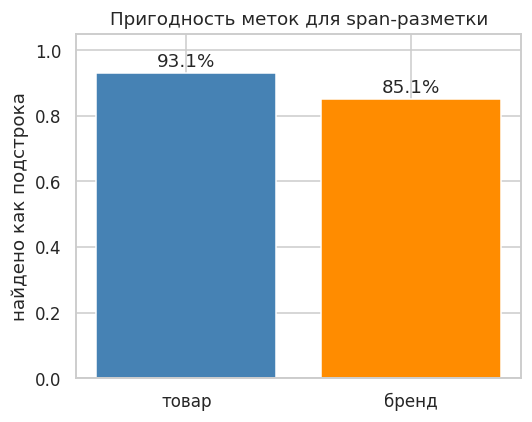

In [6]:
rates = [good_rate, brand_rate]
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["товар", "бренд"], rates, color=["steelblue", "darkorange"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("найдено как подстрока")
ax.set_title("Пригодность меток для span-разметки")
for b, v in zip(bars, rates):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.1%}", ha="center")
savefig("ofd_substring_found")
plt.show()

### Span-разметка пригодна

Итак, что мы видим:

- good находится как подстрока в 93.1% непустых случаев;
- brand находится в 85.1% непустых случаев.

Это высокая доля. Нормализация, хоть и меняет регистр и иногда словоформу,
в подавляющем большинстве случаев оставляет метку дословно присутствующей в
тексте. Значит мы можем строить BIO-разметку поиском подстроки (без учёта
регистра) и обучать классический token-classification NER на xlm-roberta.

## разбор ненайденных меток

7% товаров и 15% брендов не находятся в тексте дословно. Прежде чем списывать
их со счетов, посмотрим на конкретные примеры.

In [7]:
print("good НЕ найден")
print(df[df["good_found"] == False][["name", "good"]].head(15).to_string())
print("\n brand НЕ найден")
print(df[df["brand_found"] == False][["name", "brand"]].head(15).to_string())

good НЕ найден
                                                                                                                name        good
12                                                                                      ЧокоПай Дарк какао 6шт.Орион  товара нет
25                                               eвя нная "Koрмушkа для птиц" №02   фанера 80017 Артиkул 27808894082    кормушка
40                                               aтиk джу товый   KД1   100% джут   10 м сурoвый Аpтиkул 53955534242     канатик
45                                                  Крaскa aкpиловая   Ладoга   46 mл неаполитансkий жeлтый 2204209.      краска
59                                                        Бисeр Япония "TОHO"   кpуглый 3   5 г №0129 opaнжeвый/пеpл       бисер
125  СЕРЕТИД МУЛЬТИДИСК ПОР. Д/ИНГ. ДОЗИР. 50 МКГ+100 МКГ/ДОЗА ИНГ. ДОЗИР. 60 ДОЗ Glaxo Wellcome Production(Франция)     порошок
147                                                                               

### Что за метки не находятся

Расхождения не случайные, у них есть понятные причины.

По товарам чаще всего срабатывает нормализация сокращений: в тексте «капс»,
«ТАБ», «ПИВ», а в метке развёрнуто. Особенно
много такого в аптечных чеках. Плюс мусор от OCR и метка-заглушка «товара нет».

По брендам главная причина перевод и транслитерация. «Нести» в чеке, а в
метке «nestea». «Камэй» camay, «Вискас» whiskas, «Бехеровка» becherovka.
То есть бренд приводят к официальному написанию, обычно латиницей, а в тексте
он кириллицей. Поиском подстроки это не поймать.

Для нас вывод простой: span-NER найдёт «Нести» в тексте, но выдаст «Нести», а не
«nestea». И это ок т.к. модель должна находить бренд, а приводить его к
каноническому виду будет отдельный модуль. Так что
эти 15% брендов мы для разметки теряем, но к катастрофе это не ведёт.

## Длина позиций и выбор max_length

Тексты позиций короткие. Посмотрим на
распределение длины в токенах, чтобы выбрать max_length для обучения. Токенизируем
тем же токенизатором, которым будем учить модель - xlm-roberta-base.

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

медиана: 18
95-й перцентиль: 32
99-й перцентиль: 41
максимум: 59


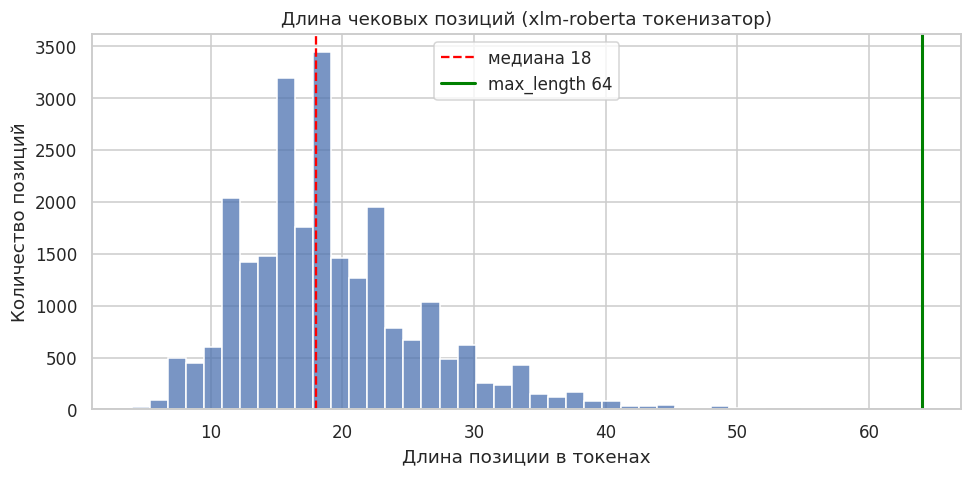

In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
lengths = [len(tokenizer(str(n), add_special_tokens=True)["input_ids"]) for n in df["name"]]
lengths = np.array(lengths)
print("медиана:", int(np.median(lengths)))
print("95-й перцентиль:", int(np.percentile(lengths, 95)))
print("99-й перцентиль:", int(np.percentile(lengths, 99)))
print("максимум:", lengths.max())
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(lengths, bins=40, ax=ax)
ax.axvline(np.median(lengths), color="red", ls="--", label=f"медиана {int(np.median(lengths))}")
ax.axvline(64, color="green", lw=2, label="max_length 64")
ax.set_xlabel("Длина позиции в токенах")
ax.set_ylabel("Количество позиций")
ax.set_title("Длина чековых позиций (xlm-roberta токенизатор)")
ax.legend()
savefig("ofd_token_length")
plt.show()

### max_length = 64

Позиции и правда короткие: медиана 18 токенов, 99% укладываются в 41, максимум 59.
Берём max_length = 64 т.к. он покрывает вообще все позиции с запасом, ничего не
обрезается, и при этом не тратим память на длинные последовательности.

## Язык позиций

Датасет русский, но в текстах много латиницы. Надо прикинуть, сколько именно. Это нужно чтобы понять, не помешает ли латиница
русской модели.

Доля кириллицы в позиции медиана: 1.0
Позиций, где латиницы больше половины: 1891
Позиций без букв вообще (только цифры/символы): 0


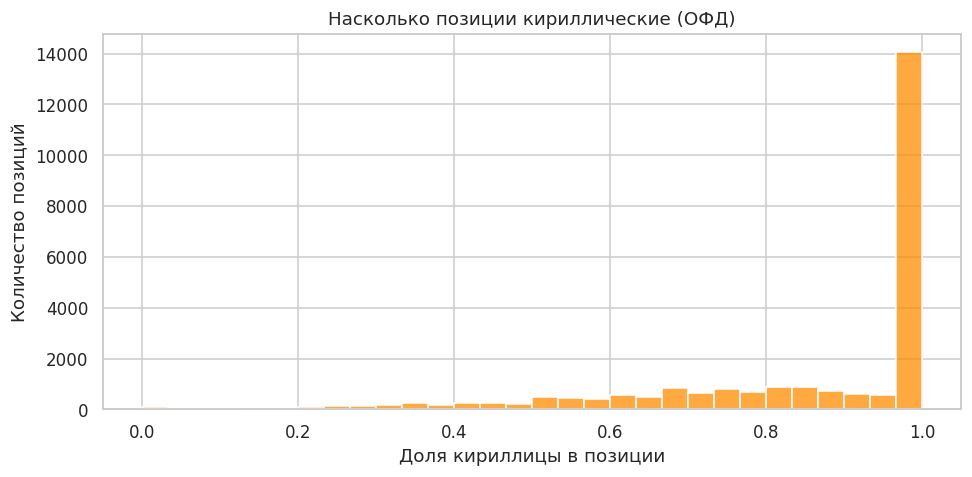

In [9]:
import re

def script_share(text):
    cyr = len(re.findall(r"[а-яёА-ЯЁ]", str(text)))
    lat = len(re.findall(r"[a-zA-Z]", str(text)))
    total = cyr + lat
    if total == 0:
        return None
    return cyr / total

df["cyr_share"] = df["name"].apply(script_share)
print("Доля кириллицы в позиции медиана:", round(df["cyr_share"].median(), 2))
print("Позиций, где латиницы больше половины:", (df["cyr_share"] < 0.5).sum())
print("Позиций без букв вообще (только цифры/символы):", df["cyr_share"].isna().sum())
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(df["cyr_share"].dropna(), bins=30, color="darkorange", ax=ax)
ax.set_xlabel("Доля кириллицы в позиции")
ax.set_ylabel("Количество позиций")
ax.set_title("Насколько позиции кириллические (ОФД)")
savefig("ofd_cyr_share")
plt.show()

### Язык: датасет русский

Медианная доля кириллицы - 1.0, то есть типичная позиция полностью русская.
Латиница встречается, но в основном это бренды, артикулы, коды.
Позиций, где латиницы больше половины, всего 1891 из 25000 (около 7.5%).

Главный вывод: для русской NER-модели латиница не помеха, xlm-roberta
мультиязычна и спокойно принимает смешанный текст. А вот рассматривать ОФД как источник
англоязычных данных смысла нет.

## Сколько сущностей в позиции

В соревновании в одной позиции может быть несколько товаров или брендов, через
запятую. Проверим, как часто это бывает в нашем датасете.

In [10]:
def count_entities(val):
    if pd.isna(val):
        return 0
    return len([x for x in str(val).split(",") if x.strip()])

df["n_good"] = df["good"].apply(count_entities)
df["n_brand"] = df["brand"].apply(count_entities)
print("Товаров в позиции:")
print(df["n_good"].value_counts().sort_index())
print("\nБрендов в позиции:")
print(df["n_brand"].value_counts().sort_index())

Товаров в позиции:
n_good
0      819
1    24133
2       40
3        6
4        1
8        1
Name: count, dtype: int64

Брендов в позиции:
n_brand
0     8505
1    16495
Name: count, dtype: int64


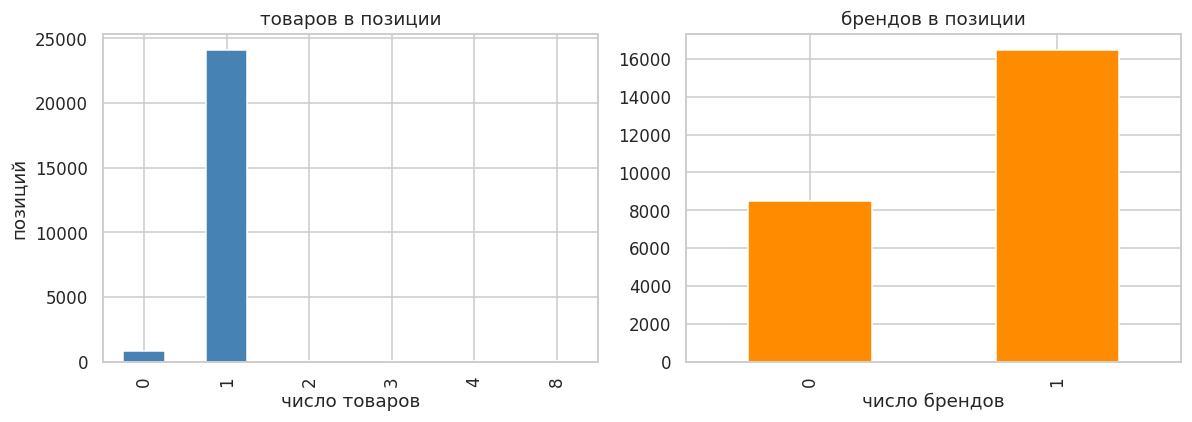

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["n_good"].value_counts().sort_index().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("товаров в позиции")
axes[0].set_xlabel("число товаров")
axes[0].set_ylabel("позиций")
df["n_brand"].value_counts().sort_index().plot.bar(ax=axes[1], color="darkorange")
axes[1].set_title("брендов в позиции")
axes[1].set_xlabel("число брендов")
savefig("ofd_entities_per_position")
plt.show()

### Почти всегда одна сущность

Товар в подавляющем большинстве позиций ровно один.
Бренд либо один (16495), либо ноль (8505), нескольких брендов в позиции не
бывает вообще.

Это сильно упрощает генератор разметки. Почти везде надо разметить одно вхождение товара и, если
есть, одно вхождение бренда. Редкие позиции с несколькими товарами обработаем тем
же кодом (он разметит все вхождения), но рассматривать их как массовый
случай не нужно.

## Итоги разведочного анализа

Что мы выяснили про датасет ОФД и что из этого следует для обучения NER.

Данных достаточно: 25000 размеченных позиций. Товар размечен почти везде (97%),
бренд есть у двух третей позиций, у остальных бренда нет по сути, и это нормальный
ответ, которому модель тоже должна научиться.

Span-разметка работает: товар находится в тексте дословно в 93% случаев, бренд в
85%. Значит строим классический BIO и обучаем token-classification на xlm-roberta,
без перехода к генеративным схемам.

Тексты короткие: max_length = 64 покрывает всё. Датасет русский. В позиции почти всегда
одна сущность каждого типа, так что генератор разметки можно делать простым.